# 17.1 Poisson Kriging of Areal Disease Data 


**Dataset:** Northeastern-US breast-cancer mortality — county polygons (`data/cancer_areas.shp`, 217 counties) + census population points (`data/cancer_data.gpkg`, 5,419 points)
**Target:** Age-adjusted breast-cancer mortality rate (`rate`, per 100,000)
**Library:** `pygstat.poisson_kriging` — centroid-based, area-to-area (ATA), and area-to-point (ATP) Poisson kriging (Goovaerts, 2006)


***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory - Poisson Risk and the Small-Number Problem](#2-theory--poisson-risk-and-the-small-number-problem)
3. [Theory - Centroid, ATA, and ATP Estimators](#3-theory--centroid-ata-and-atp-estimators)
4. [Theory - Population-Weighted Variogram and Deconvolution](#4-theory--population-weighted-variogram-and-deconvolution)
5. [Python Setup](#5-python-setup)
6. [Load Data and Point Support](#6-load-data-and-point-support)
7. [Exploratory Maps](#7-exploratory-maps)
8. [Semivariogram Model](#8-semivariogram-model)
9. [Population-Weighted Distance and Risk Semivariogram](#9-population-weighted-distance-and-risk-semivariogram)
10. [Deconvolution to Point Support](#10-deconvolution-to-point-support)
11. [Run the Three Estimators](#11-run-the-three-estimators)
12. [Area-to-Point Surface](#12-area-to-point-surface)
13. [Coherence Constraint](#13-coherence-constraint)
14. [Kriging-Variance Comparison](#14-kriging-variance-comparison)
15. [CPU vs GPU Poisson Kriging Timing](#15-cpu-vs-gpu-poisson-kriging-timing)
16. [Summary and Conclusions](#16-summary-and-conclusions)
17. [Resources](#17-resources)


***
## 1. Overview

**Poisson kriging** interpolates an areal *rate* $z(v)=d(v)/n(v)$ while respecting that $d$ is a Poisson count over a population at risk $n$. A county with a few thousand residents produces a far noisier rate than one with a million, even if their true underlying risk $R$ is the same (the *small-number problem*). Ordinary kriging of the raw rate ignores this and lets small, noisy counties distort the map.

Goovaerts (2006) gives three Poisson-kriging estimators that fold $\mathrm{Var}(z)\propto 1/n$ into the kriging diagonal:

| Estimator | Support | What it produces |
|---|---|---|
| **Centroid PK** | point $\to$ point | risk at county centroids |
| **Area-to-area (ATA)** | area $\to$ area | risk for each county polygon |
| **Area-to-point (ATP)** | area $\to$ point | a continuous isopleth surface |

`pygstat.poisson_kriging` implements all three. This notebook supplies the surrounding *variogram inference* (population-weighted risk semivariogram and deconvolution to point support), loads the Northeastern-US breast-cancer mortality data, runs the three estimators, and checks the ATP **coherence constraint**.

| Step | What we do |
|---|---|
| Data | 217 county polygons + 5,419 census points; build `PointSupport` per county |
| Variogram | Population-weighted risk $\gamma_R(h)$ (Monestiez/Goovaerts Eq. 5) |
| Deconvolution | Invert regularisation to a point-support model (Eq. 18) |
| Mapping | Leave-one-out centroid and ATA maps; ATP on a 12 km grid |
| Check | Population-weighted ATP average equals ATA (Eq. 15, machine precision) |
| CPU / GPU | Time k-NN `PoissonKriging.predict` on CPU vs GPU using **USA diabetes** counties (`usa_diabetes_data.csv` + `US_COUNTY.shp`, $n=3{,}107$) |

By the end you will have leave-one-out centroid and ATA maps, an ATP isopleth that satisfies the coherence constraint, and a CPU vs GPU timing of the batched k-NN centroid solve on the national diabetes county set.


***
## 2. Theory - Poisson Risk and the Small-Number Problem

Let $v_\alpha$ be a county with population $n(v_\alpha)$ and observed count $d(v_\alpha)$. The latent **risk** $R$ is the intensity of a Poisson count,

$$
d(v_\alpha)\sim\mathrm{Poisson}\big(n(v_\alpha)\,R(v_\alpha)\big),
\qquad
z(v_\alpha)=B\,\frac{d(v_\alpha)}{n(v_\alpha)},
$$

where $B$ is a rate base (here $10^5$, rates per 100,000). Because $\mathrm{Var}(d)=\mathbb{E}[d]$, the rate is heteroscedastic:

$$
\mathrm{Var}\big(z(v_\alpha)\big)\;\approx\;
B\,\frac{m^\ast}{n(v_\alpha)},
\qquad
m^\ast=\frac{\sum_\alpha d(v_\alpha)}{\sum_\alpha n(v_\alpha)}.
$$

The Poisson-kriging system is ordinary kriging of $z$ for $R$, with that population-dependent variance added to the diagonal so small-population areas are automatically down-weighted. `rate_base` ($B$) is **auto-detected** from the rate magnitude; without it the penalty is $\sim 10^5\times$ too small and ATA/ATP become unstable.


***
## 3. Theory - Centroid, ATA, and ATP Estimators

All three estimators are linear, $\hat R=\sum_i\lambda_i z_i$, with a population penalty on the kriging diagonal and the unbiasedness constraint $\sum_i\lambda_i=1$.

**Centroid (Goovaerts 2006, Eq. 3).** Areas are collapsed to population-weighted centroids $\mathbf{u}_i$. The system is

$$
\sum_j\lambda_j\Big[C_R(\mathbf{u}_i-\mathbf{u}_j)
+\delta_{ij}\tfrac{m^\ast}{n(\mathbf{u}_i)}\Big]+\mu
=C_R(\mathbf{u}_i-\mathbf{u}_\alpha).
$$

This is `PoissonKriging.predict_id`. It is fast, but it ignores the size and shape of each county.

**Area-to-area (Eq. 7).** Point covariances are replaced by *block* covariances averaged over each county's census points,

$$
\bar C_R(v_i,v_j)
=\frac{\sum_{s,s'} n_s n_{s'} C(\mathbf{u}_s-\mathbf{u}_{s'})}
{\sum_{s,s'} n_s n_{s'}}.
$$

This is `AreaPoissonKriging.predict_area`. Change of support usually shrinks the kriging variance relative to the centroid estimator.

**Area-to-point (Eq. 13–14).** Same left-hand side as ATA; the right-hand side uses area-to-point covariances $\bar C_R(v_i,\mathbf{u}_s)$. Solving at every grid node produces a continuous isopleth (`AreaPoissonKriging.predict_points`).

**Coherence (Eq. 15).** The population-weighted average of ATP estimates inside a county must recover the ATA estimate for that county:

$$
\sum_s \frac{n(\mathbf{u}_s)}{\sum_{s'}n(\mathbf{u}_{s'})}
\hat R(\mathbf{u}_s)=\hat R(v_\alpha).
$$


***
## 4. Theory - Population-Weighted Variogram and Deconvolution

The kriging engine consumes a **point-support** covariance $C_R(h)$. Observed rates are areal, so two inference steps are needed.

**Population-weighted risk semivariogram (Monestiez / Goovaerts Eq. 5).** Unreliable pairs are down-weighted and the Poisson noise variance is removed:

$$
\hat\gamma_R(h)=\frac{1}{2\sum_\alpha w_\alpha}
\sum_\alpha w_\alpha\Big[(z_\alpha-z_{\alpha+h})^2-m^\ast\Big],
\quad
w_\alpha=\frac{n_\alpha n_{\alpha+h}}{n_\alpha+n_{\alpha+h}}.
$$

Distances between counties use the **population-weighted distance** (Eq. 1) between their census-point clouds, not the Euclidean distance between centroids.

**Deconvolution (Eq. 18).** ATA/ATP need the point-support model. Regularisation relates areal and point semivariograms by

$$
\gamma_v(h)=\bar\gamma(v,v_h)-\bar\gamma_h(v,v).
$$

We invert this iteratively, reusing the module's block-semivariance helpers (`_weighted_semivariance`, `_within_support_semivariance`) so the regularisation is consistent with the kriging engine. The result is a point-support model with a **higher sill** than the areal one — the extra variance that change of support had averaged away.


***
## 5. Python Setup

### 5.1 CPU and GPU

`PoissonKriging.predict` solves a **local** Poisson-kriging system at every prediction
point. In k-nearest-neighbor mode every point has the same neighbor count $k$, so
pygstat stacks the systems into one `(n_{\mathrm{pred}}, k+1, k+1)` batched
`xp.linalg.solve` — NumPy on CPU, CuPy on GPU. Pass `use_gpu='auto'|True|False`.

| Argument / method | What it controls |
|-------------------|------------------|
| `use_gpu` | Batched k-NN centroid Poisson-kriging solve (NumPy or CuPy). |
| `predict_id` | Leave-one-out of a single area; stays on **CPU**. |
| `AreaPoissonKriging` | ATA / ATP block covariances; stays on **CPU**. |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in
`USE_GPU`. The Northeastern-US cancer maps in §11–14 use `predict_id` / ATA / ATP
(CPU). **§15** times the k-NN GPU path on **USA county diabetes** ($n = 3{,}107$).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from shapely.geometry import Point
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares
# --- Poisson kriging engine ---
import pygstat
from pygstat import poisson_kriging as pk
from pygstat.poisson_kriging import (
    PoissonKriging,
    AreaPoissonKriging,
    PointSupport,
    _weighted_semivariance as wgamma,
    _within_support_semivariance as within_gamma,
    _detect_rate_base,
)

plt.rcParams.update({"figure.dpi":110, "font.size":10,
                     "axes.spines.top":False, "axes.spines.right":False})
np.set_printoptions(suppress=True)
print("geopandas", gpd.__version__)
print("pygstat version:", pygstat.__version__)

from pygstat import Variogram
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

# ── Poisson k-NN batched solve: CPU / GPU dispatch (CuPy) ──────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — PoissonKriging k-NN batched solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788927970.930946  695373 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


geopandas 1.1.4
pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — PoissonKriging k-NN batched solve on GPU
use_gpu         : True


***
## 6. Load Data and Point Support

217 county polygons (`FIPS`, age-adjusted `rate` per 100,000) and 5,419 census population points (`POP10`). A rate from a small population is noisy, so each county needs its **point support** and **total population**. Points are assigned to counties by a `within` join, with stragglers snapped to the nearest county; `PointSupport` then groups them.


In [2]:
areas = gpd.read_file("../data/cancer_areas.shp"); areas["FIPS"] = areas["FIPS"].astype(int)
pts   = gpd.read_file("../data/cancer_data.gpkg", layer="points").set_crs(areas.crs, allow_override=True)

j = gpd.sjoin(pts, areas[["FIPS","geometry"]], how="left", predicate="within")
miss = j["FIPS"].isna()
if miss.any():
    jn = gpd.sjoin_nearest(pts[miss.values], areas[["FIPS","geometry"]], how="left")
    j.loc[miss.values, "FIPS"] = jn["FIPS"].values
j["FIPS"] = j["FIPS"].astype(int)

pxy = np.column_stack([j.geometry.x, j.geometry.y])
ps  = PointSupport(pxy, j["POP10"].values, j["FIPS"].values)   # <-- module class

pop_area = j.groupby("FIPS")["POP10"].sum()
areas["pop"] = areas["FIPS"].map(pop_area)
fips  = areas["FIPS"].values
rates = areas["rate"].values
pops  = areas["pop"].values
cent  = np.array([ps.centroid(int(f)) for f in fips])          # pop-weighted centroids
areas["cx"], areas["cy"] = cent[:,0], cent[:,1]

print(f"{len(areas)} counties | {len(j)} points ({miss.sum()} snapped) | {len(ps)} supports")
print(f"population/county: {pops.min():,.0f}–{pops.max():,.0f} (median {np.median(pops):,.0f})")
print(f"rate/100k: {rates.min():.1f}–{rates.max():.1f} (mean {rates.mean():.1f})")

217 counties | 5419 points (459 snapped) | 217 supports
population/county: 4,886–2,371,499 (median 104,290)
rate/100k: 98.1–192.2 (mean 131.6)


***
## 7. Exploratory Maps


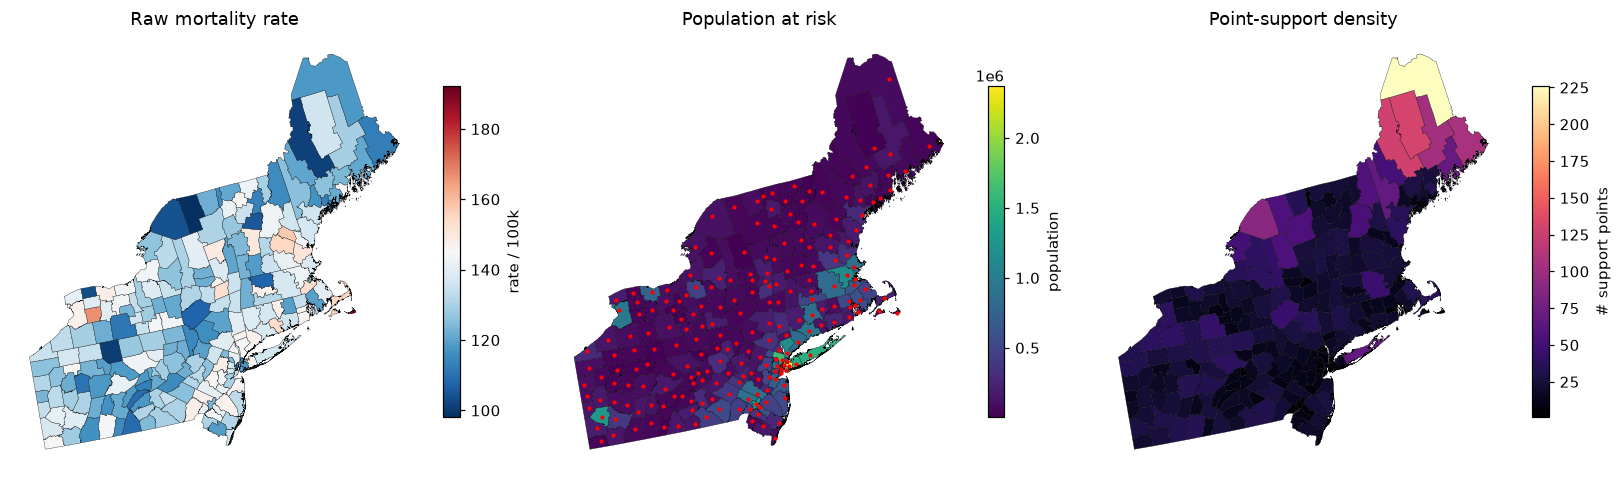

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
areas.plot("rate", cmap="RdBu_r", legend=True, ax=ax[0], edgecolor="k", linewidth=.2,
           legend_kwds={"label":"rate / 100k","shrink":.7}); ax[0].set_title("Raw mortality rate")
areas.plot("pop", cmap="viridis", legend=True, ax=ax[1], edgecolor="k", linewidth=.2,
           norm=Normalize(), legend_kwds={"label":"population","shrink":.7})
ax[1].scatter(cent[:,0], cent[:,1], s=3, c="red"); ax[1].set_title("Population at risk")
areas["npts"] = areas["FIPS"].map(j.groupby("FIPS").size())
areas.plot("npts", cmap="magma", legend=True, ax=ax[2], edgecolor="k", linewidth=.2,
           legend_kwds={"label":"# support points","shrink":.7}); ax[2].set_title("Point-support density")
for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()

***
## 8. Semivariogram Model

`AreaPoissonKriging` / `PoissonKriging` expect a `variogram` with `fitted_params = [nugget, partial_sill, range]` that is callable as `variogram(h) → γ(h)`. We supply this small `VariogramModel`; the range is capped at the largest lag so it cannot rail past the domain.


In [4]:
def _spherical(h, n, ps_, r):
    h = np.asarray(h, float); g = np.where(h <= r, ps_*(1.5*h/r - 0.5*(h/r)**3), ps_)
    return n + np.where(h == 0, 0.0, g)
def _exponential(h, n, ps_, r):
    h = np.asarray(h, float); return n + np.where(h == 0, 0.0, ps_*(1-np.exp(-3*h/r)))
_MODELS = {"spherical":_spherical, "exponential":_exponential}

class VariogramModel:
    """Callable gamma(h) with fitted_params = [nugget, psill, range]."""
    def __init__(self, model="spherical", nugget=0.0, psill=1.0, rng=1.0):
        self.model = model; self.fitted_params = [nugget, psill, rng]
    def __call__(self, h):
        return _MODELS[self.model](h, *self.fitted_params)
    @property
    def sill(self):
        return self.fitted_params[0] + self.fitted_params[1]
    def fit(self, lags, gamma, weights=None):
        lags, gamma = np.asarray(lags, float), np.asarray(gamma, float)
        w = np.ones_like(gamma) if weights is None else np.asarray(weights, float)
        s0 = gamma.max()
        def resid(p):
            return (_MODELS[self.model](lags, *p) - gamma)*np.sqrt(w)
        sol = least_squares(resid, [gamma.min(), s0, lags[len(lags)//2]],
                            bounds=([0,0,lags.min()], [s0, 3*s0, lags.max()]))
        self.fitted_params = list(sol.x); return self

***
## 9. Population-Weighted Distance and Risk Semivariogram

The Monestiez/Goovaerts estimator down-weights unreliable pairs and removes the Poisson noise variance (Eq. 5). Distances are the population-weighted distances of Eq. 1.


areal risk model: nugget=37.1  sill=78.0  range=590 km


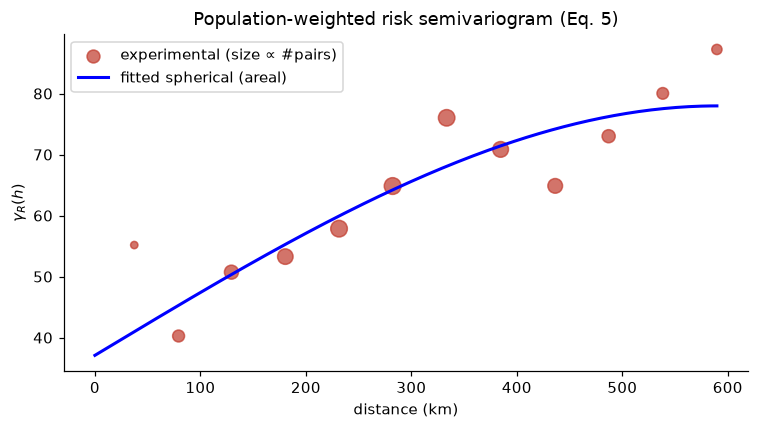

In [5]:
def pop_weighted_distance(ca, va, cb, vb):
    """Eq. 1: population-weighted mean distance between two point supports."""
    d = cdist(ca, cb); w = np.outer(va, vb); tw = w.sum()
    return float((d*w).sum()/tw) if tw > 0 else float(d.mean())

def risk_semivariogram(coords, rates, pops, n_lags=12, max_dist=None):
    """Eq. 5: population-weighted, Poisson-corrected experimental risk semivariogram."""
    d = cdist(coords, coords); iu = np.triu_indices(len(coords), 1)
    dd, zi, zj = d[iu], rates[iu[0]], rates[iu[1]]
    ni, nj = pops[iu[0]], pops[iu[1]]
    mstar = np.sum(rates*pops)/np.sum(pops)
    w    = ni*nj/(ni+nj)
    incr = (zi-zj)**2 - mstar
    if max_dist is None: max_dist = dd.max()/2
    edges = np.linspace(0, max_dist, n_lags+1)
    L, G, N = [], [], []
    for k in range(len(edges)-1):
        m = (dd > edges[k]) & (dd <= edges[k+1])
        if m.sum() < 5: continue
        L.append(dd[m].mean()); G.append(np.sum(w[m]*incr[m])/(2*np.sum(w[m]))); N.append(int(m.sum()))
    return np.array(L), np.clip(np.array(G), 0, None), np.array(N)

dmax = cdist(cent, cent).max()
lags, gam, npair = risk_semivariogram(cent, rates, pops, n_lags=12, max_dist=dmax*0.5)
vg_area = VariogramModel("spherical").fit(lags, gam, weights=npair)
print(f"areal risk model: nugget={vg_area.fitted_params[0]:.1f}  sill={vg_area.sill:.1f}  "
      f"range={vg_area.fitted_params[2]/1000:.0f} km")

hh = np.linspace(0, lags.max(), 200)
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(lags/1000, gam, s=npair/npair.max()*120, c="#c0392b", alpha=.7,
           label="experimental (size ∝ #pairs)")
ax.plot(hh/1000, vg_area(hh), "b-", lw=2, label="fitted spherical (areal)")
ax.set_xlabel("distance (km)"); ax.set_ylabel(r"$\gamma_R(h)$")
ax.set_title("Population-weighted risk semivariogram (Eq. 5)"); ax.legend()
plt.tight_layout(); plt.show()

***
## 10. Deconvolution to Point Support

ATA/ATP need the **point-support** model. We invert $\gamma_v(h)=\bar\gamma(v,v_h)-\bar\gamma_h(v,v)$ iteratively, reusing the module's own block-semivariance helpers so the regularisation is consistent with the kriging engine.


point-support model: nugget=74.2  sill=156.0  range=590 km  (D=0.294, 4 iters)
areal sill=78.0 -> point-support sill=156.0 (higher, as expected)


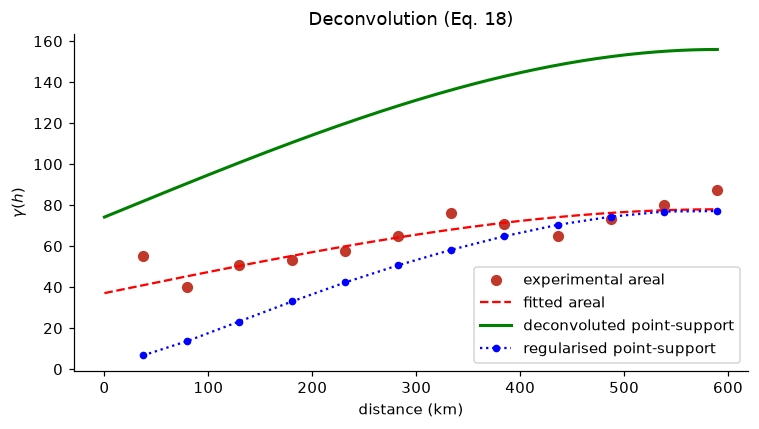

In [6]:
def regularize(vg_pt, ps, ids, centd, lags, lag_tol):
    """Regularise a point-support model to a theoretical areal gamma_v(h) (Eq. 18)."""
    within = np.array([within_gamma(vg_pt, ps.coords(int(b)), ps.values(int(b))) for b in ids])
    iu = np.triu_indices(len(ids), 1)
    gv = np.full(len(lags), np.nan)
    for li, h in enumerate(lags):
        m = (centd[iu] > h-lag_tol) & (centd[iu] <= h+lag_tol)
        ii, jj = iu[0][m], iu[1][m]
        if len(ii) < 3: continue
        vals = [wgamma(vg_pt, ps.coords(int(ids[a])), ps.values(int(ids[a])),
                       ps.coords(int(ids[b])), ps.values(int(ids[b]))) - 0.5*(within[a]+within[b])
                for a, b in zip(ii, jj)]
        gv[li] = np.mean(vals)
    return gv

def deconvolute(vg_area, ps, ids, centd, lags, exp_gamma, lag_tol, max_iter=12, tol=0.01):
    vg_pt = VariogramModel(vg_area.model, *vg_area.fitted_params)
    reg = regularize(vg_pt, ps, ids, centd, lags, lag_tol)
    good = np.isfinite(reg) & np.isfinite(exp_gamma)
    dev = lambda a, b: np.mean(np.abs(a-b)/np.where(b>0, b, 1))
    bestD, hist = dev(reg[good], exp_gamma[good]), []
    best = vg_pt; hist.append(bestD)
    for _ in range(max_iter):
        r = np.where((reg > 0) & np.isfinite(reg), exp_gamma/reg, 1.0)
        s = float(np.clip(np.nanmean(r), 0.5, 2.0))
        n, psl, rng = best.fitted_params
        cand = VariogramModel(best.model, n*s, psl*s, rng)
        reg2 = regularize(cand, ps, ids, centd, lags, lag_tol)
        g2 = np.isfinite(reg2) & np.isfinite(exp_gamma)
        D = dev(reg2[g2], exp_gamma[g2]); hist.append(D)
        if D < bestD: best, bestD, reg = cand, D, reg2
        if len(hist) > 3 and abs(hist[-2]-hist[-1]) < tol*hist[0]: break
    return best, bestD, hist

centd   = cdist(cent, cent)
lag_tol = (lags[1]-lags[0])/2
vg_pt, Dstat, hist = deconvolute(vg_area, ps, fips, centd, lags, gam, lag_tol)
reg_final = regularize(vg_pt, ps, fips, centd, lags, lag_tol)
print(f"point-support model: nugget={vg_pt.fitted_params[0]:.1f}  sill={vg_pt.sill:.1f}  "
      f"range={vg_pt.fitted_params[2]/1000:.0f} km  (D={Dstat:.3f}, {len(hist)} iters)")
print(f"areal sill={vg_area.sill:.1f} -> point-support sill={vg_pt.sill:.1f} (higher, as expected)")

fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(lags/1000, gam, s=40, c="#c0392b", label="experimental areal")
ax.plot(hh/1000, vg_area(hh), "r--", lw=1.5, label="fitted areal")
ax.plot(hh/1000, vg_pt(hh),  "g-",  lw=2,   label="deconvoluted point-support")
ax.plot(lags/1000, reg_final, "b:o", ms=4, lw=1.5, label="regularised point-support")
ax.set_xlabel("distance (km)"); ax.set_ylabel(r"$\gamma(h)$")
ax.set_title("Deconvolution (Eq. 18)"); ax.legend(); plt.tight_layout(); plt.show()

***
## 11. Run the Three Estimators

We pass the deconvoluted point-support model and let `rate_base` auto-detect. Centroid and ATA run leave-one-out (each county predicted from the others) so predictions can be scored against observed rates.


In [7]:
K = 16
pk_cent = PoissonKriging(vg_pt).fit(cent, rates, pops, ids=fips)          # module class
apk     = AreaPoissonKriging(vg_pt).fit(ps, pd.Series(rates, index=fips)) # module class
print(f"auto-detected rate_base: centroid={pk_cent.rate_base:.0f}  area={apk.rate_base:.0f}")

cpk = [pk_cent.predict_id(int(f), number_of_neighbors=K) for f in fips]
ata = [apk.predict_area(int(f), number_of_neighbors=K)   for f in fips]

zc = np.array([r["zhat"] for r in cpk]); sc = np.array([r["sig"] for r in cpk])
za = np.array([r["zhat"] for r in ata]); sa = np.array([r["sig"] for r in ata])
areas["z_centroid"], areas["s_centroid"] = zc, sc
areas["z_ata"],      areas["s_ata"]      = za, sa

def st(z): return (z-rates).mean(), np.abs(z-rates).mean(), z.var()
pd.DataFrame({
    "ME":  [np.nan, st(zc)[0], st(za)[0]],
    "MAE": [np.nan, st(zc)[1], st(za)[1]],
    "variance": [rates.var(), zc.var(), za.var()],
    "mean kriging sd": [np.nan, np.nanmean(sc), np.nanmean(sa)],
}, index=["raw rates","Centroid PK","ATA PK"]).round(3)

auto-detected rate_base: centroid=100000  area=100000


,ME,MAE,variance,mean kriging sd
raw rates,NaN,NaN,171.273,NaN
Centroid PK,1.755,9.326,23.833,9.621
ATA PK,1.914,9.333,24.326,3.699


Centroid and ATA agree on the risk (similar ME/MAE), but ATA's **kriging standard deviation is far smaller** — the change-of-support pay-off of respecting each county's area and population. Both are much smoother than the raw map.


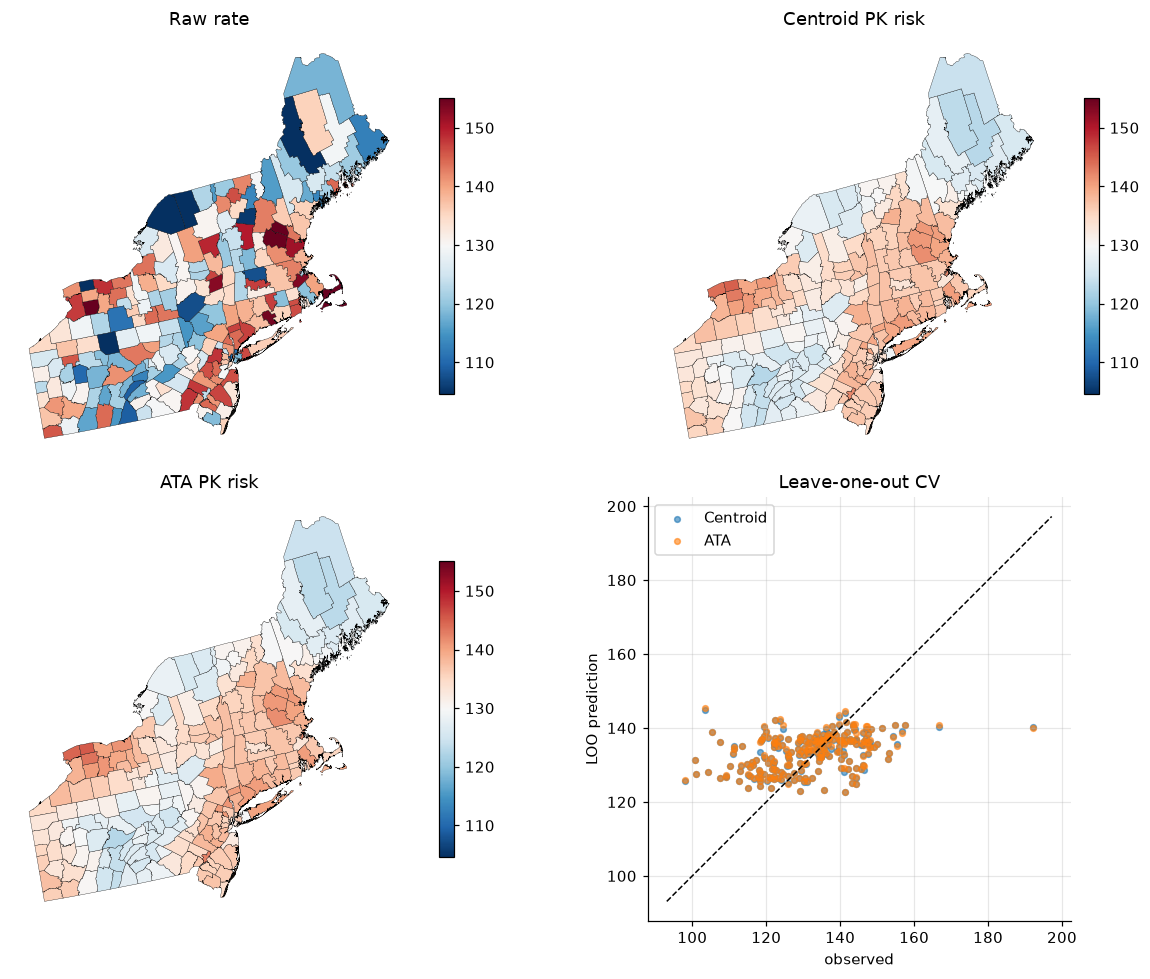

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
vmin, vmax = np.percentile(rates, 2), np.percentile(rates, 98)
for a, col, ttl in [(ax[0,0],"rate","Raw rate"), (ax[0,1],"z_centroid","Centroid PK risk"),
                    (ax[1,0],"z_ata","ATA PK risk")]:
    areas.plot(col, cmap="RdBu_r", ax=a, vmin=vmin, vmax=vmax, edgecolor="k",
               linewidth=.2, legend=True, legend_kwds={"shrink":.7}); a.set_title(ttl); a.set_axis_off()
ax[1,1].scatter(rates, zc, s=14, alpha=.6, label="Centroid")
ax[1,1].scatter(rates, za, s=14, alpha=.6, label="ATA")
lim=[rates.min()-5, rates.max()+5]; ax[1,1].plot(lim, lim, "k--", lw=1)
ax[1,1].set_xlabel("observed"); ax[1,1].set_ylabel("LOO prediction")
ax[1,1].set_title("Leave-one-out CV"); ax[1,1].legend(); ax[1,1].set_aspect("equal"); ax[1,1].grid(alpha=.3)
plt.tight_layout(); plt.show()

***
## 12. Area-to-Point Surface

`predict_points` accepts arbitrary `targets`, so we evaluate ATP on a 12 km grid. Each node inherits the block-kriging system of its containing county (only the area-to-point RHS is recomputed), giving a continuous **isopleth** surface.


ATP surface: 2988 nodes | risk 121.5–145.6 | variance 29.5 (ATA 24.3, less smoothed)


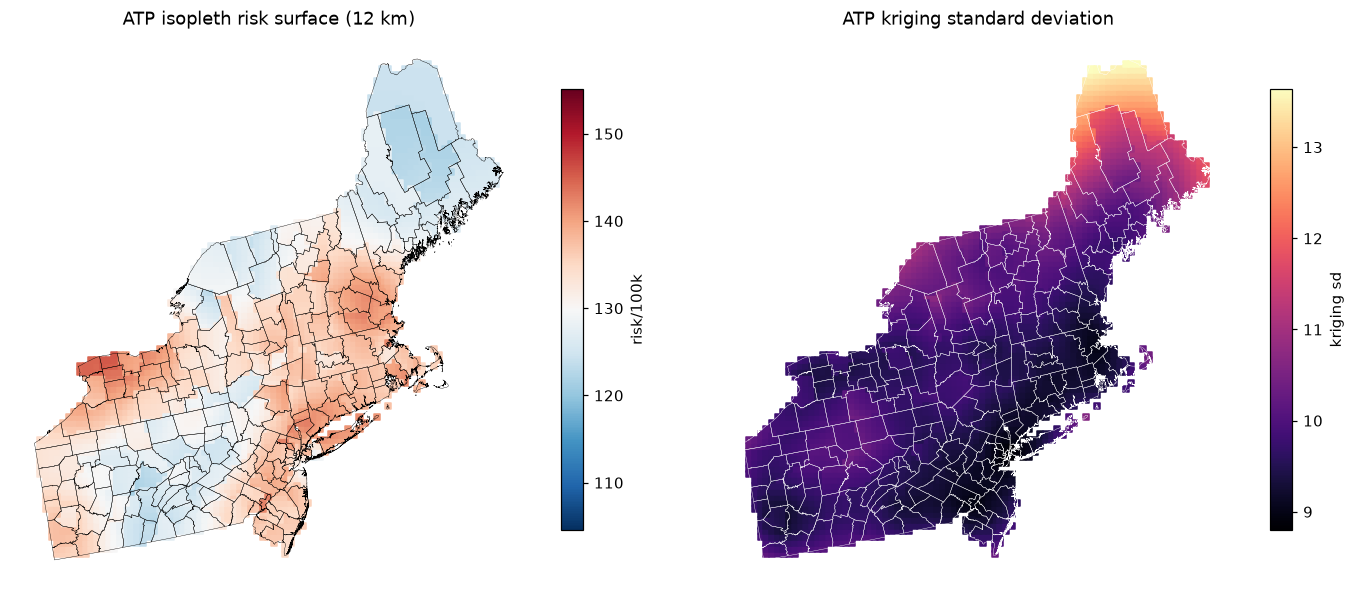

In [9]:
step = 12_000
minx, miny, maxx, maxy = areas.total_bounds
gx, gy = np.meshgrid(np.arange(minx, maxx, step), np.arange(miny, maxy, step))
grid = gpd.GeoDataFrame(geometry=[Point(x,y) for x,y in zip(gx.ravel(), gy.ravel())], crs=areas.crs)
gj = gpd.sjoin(grid, areas[["FIPS","geometry"]], how="inner", predicate="within")

parts = []
for fid, sub in gj.groupby("FIPS"):
    tgt = np.column_stack([sub.geometry.x, sub.geometry.y])
    d = apk.predict_points(int(fid), number_of_neighbors=K, targets=tgt)   # <-- module ATP
    d["FIPS"] = int(fid); parts.append(d)
atp = pd.concat(parts, ignore_index=True)
print(f"ATP surface: {len(atp)} nodes | risk {atp.zhat.min():.1f}–{atp.zhat.max():.1f} "
      f"| variance {atp.zhat.var():.1f} (ATA {za.var():.1f}, less smoothed)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
vmin, vmax = np.percentile(rates, 2), np.percentile(rates, 98)
s1 = ax[0].scatter(atp.x, atp.y, c=atp.zhat, cmap="RdBu_r", s=16, vmin=vmin, vmax=vmax, marker="s")
areas.boundary.plot(ax=ax[0], color="k", linewidth=.25); plt.colorbar(s1, ax=ax[0], shrink=.8, label="risk/100k")
ax[0].set_title("ATP isopleth risk surface (12 km)")
s2 = ax[1].scatter(atp.x, atp.y, c=atp.sig, cmap="magma", s=16, marker="s")
areas.boundary.plot(ax=ax[1], color="w", linewidth=.25); plt.colorbar(s2, ax=ax[1], shrink=.8, label="kriging sd")
ax[1].set_title("ATP kriging standard deviation")
for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()

***
## 13. Coherence Constraint

With the module's corrected ATP, the **population-weighted average** of a county's point estimates equals its ATA estimate — verified to machine precision (Eq. 15).


In [10]:
rows = []
for fid in fips[:8]:
    a  = apk.predict_area(int(fid), number_of_neighbors=K)
    pp = apk.predict_points(int(fid), number_of_neighbors=K)   # county's own support points
    wavg = np.sum(pp.zhat*pp.population)/pp.population.sum()
    rows.append([int(fid), a["zhat"], wavg, abs(a["zhat"]-wavg), len(pp)])
coh = pd.DataFrame(rows, columns=["FIPS","ATA estimate","pop-wtd avg of ATP","abs diff","# points"])
print("max coherence error:", f"{coh['abs diff'].max():.2e}")
coh.round(4)

max coherence error: 5.68e-14


,FIPS,ATA estimate,pop-wtd avg of ATP,abs diff,# points
0,25019,140.0914,140.0914,0.0,8
1,36121,140.7116,140.7116,0.0,18
2,33001,140.7006,140.7006,0.0,15
3,25007,138.7217,138.7217,0.0,17
4,25001,135.2036,135.2036,0.0,38
5,33013,140.7808,140.7808,0.0,26
6,9007,137.6608,137.6608,0.0,14
7,25021,133.1922,133.1922,0.0,13


***
## 14. Kriging-Variance Comparison


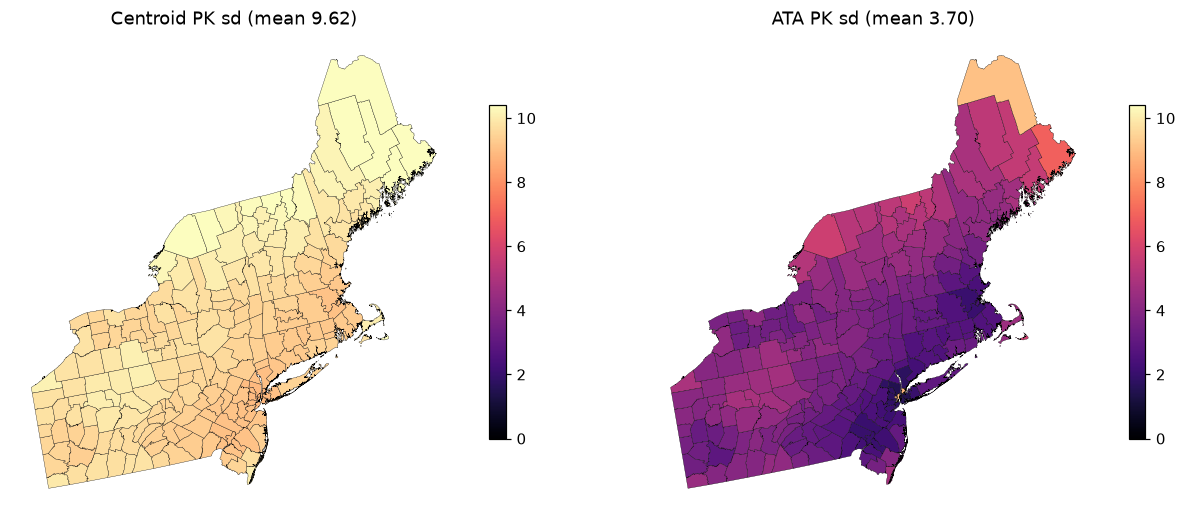

Summary
  raw-rate variance .........   171.27
  Centroid PK variance ......    23.83  (14% of raw)
  ATA PK variance ...........    24.33  (14% of raw)
  ATP surface variance ......    29.54  (less smoothed than ATA)
  mean sd  centroid / ATA ... 9.62 / 3.70
  max coherence error ....... 5.7e-14


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
smax = np.nanpercentile(np.r_[sc, sa], 98)
areas.plot("s_centroid", cmap="magma", ax=ax[0], vmin=0, vmax=smax, edgecolor="k",
           linewidth=.2, legend=True, legend_kwds={"shrink":.7})
ax[0].set_title(f"Centroid PK sd (mean {np.nanmean(sc):.2f})")
areas.plot("s_ata", cmap="magma", ax=ax[1], vmin=0, vmax=smax, edgecolor="k",
           linewidth=.2, legend=True, legend_kwds={"shrink":.7})
ax[1].set_title(f"ATA PK sd (mean {np.nanmean(sa):.2f})")
for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()

print("Summary")
print(f"  raw-rate variance ......... {rates.var():8.2f}")
print(f"  Centroid PK variance ...... {zc.var():8.2f}  ({100*zc.var()/rates.var():.0f}% of raw)")
print(f"  ATA PK variance ........... {za.var():8.2f}  ({100*za.var()/rates.var():.0f}% of raw)")
print(f"  ATP surface variance ...... {atp.zhat.var():8.2f}  (less smoothed than ATA)")
print(f"  mean sd  centroid / ATA ... {np.nanmean(sc):.2f} / {np.nanmean(sa):.2f}")
print(f"  max coherence error ....... {coh['abs diff'].max():.1e}")

***
## 15. CPU vs GPU Poisson Kriging Timing

The 217-county Northeastern-US cancer set is too small for a GPU comparison: the
batched Poisson-kriging solve is a stack of tiny $(k+1)\times(k+1)$ systems, and
host→device copies dominate. Here we time **k-nearest-neighbor** centroid Poisson
kriging (`PoissonKriging.predict`) on **CPU** (`use_gpu=False`) versus **GPU**
(`use_gpu=True`) using **USA county diabetes prevalence**.

Data:

1. Join `data/usa_diabetes_data.csv` (3,107 counties) to `data/US_COUNTY.shp` on
   `FIPS`. Coordinates are NAD 1983 Albers metres (same CRS as the polygons).
2. The target is the county diabetes percentage (`Diabetes_per`); population
   support is `POP_Total`. `rate_base=100` because the rate is a percentage.
3. Fit one exponential `pygstat.Variogram` on the 3,107 centroids (fitting $\gamma$
   is **not** in the times). Draw a separate prediction set in the county bounding
   box.

Unlike global ordinary kriging, Poisson kriging's GPU work scales with
**$n_{\mathrm{pred}}$** (one stacked solve of shape `(n_pred, k+1, k+1)`), not
$n_{\mathrm{train}}^3$. Training size is therefore held at 3,107 and we vary
$n_{\mathrm{pred}}$. Neighborhood size is $k=16$, the same $K$ as §11.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU
warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel
here, the GPU column is skipped. ATA / ATP are not timed: block-to-block
covariances are not a fixed-$k$ stack.


USA county diabetes (centroid Poisson kriging)
  counties   : 3,107 joined on FIPS (usa_diabetes_data.csv + US_COUNTY.shp)
  rate       : Diabetes_per  [3.84, 16.96] %
  population : POP_Total     [150, 10077819]
  variogram  : exponential  nugget=1.4023  partial sill=1.2185  range=613.1 km
  CRS        : NAD 1983 Albers (metres)

GPU usable : True
Repeats    : 3  (median wall time of PK fit + predict, k-NN)
n_train    : 3107  (USA diabetes counties)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the US_COUNTY bbox)
neighbors  : 16; rate_base=100 (percentage)

     dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
USA diabetes     3107     500       9.3       4.1   2.25×   True
USA diabetes     3107    1000      17.1       5.4   3.13×   True
USA diabetes     3107    2000      34.3       7.8   4.41×   True
USA diabetes     3107    4000      79.7      12.8   6.24×   True
USA diabetes     3107    8000     163.2      23.6   6.93×   True



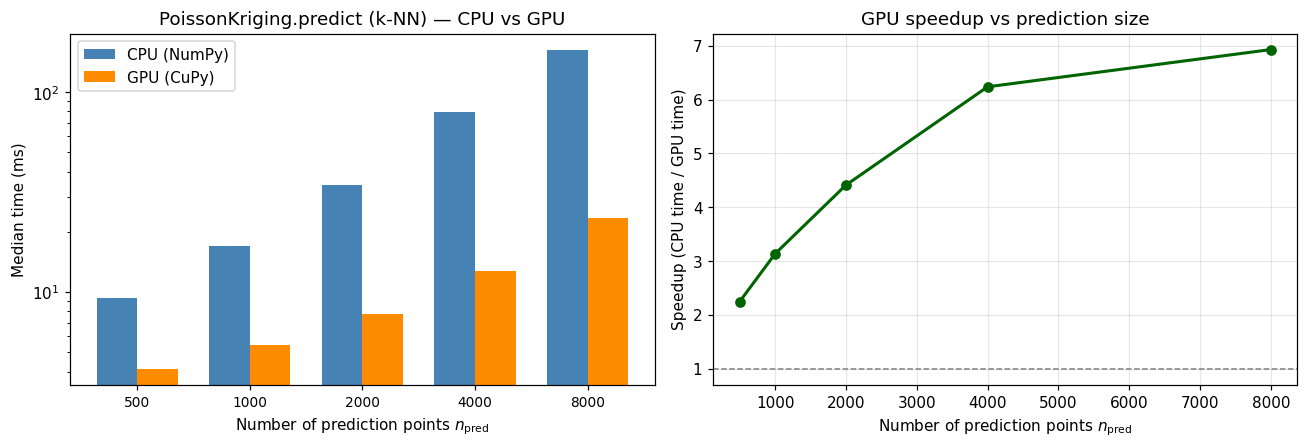

In [23]:
import time

from pygstat import Variogram

N_REPEATS = 3
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
K = 16
RATE_BASE = 100.0  # Diabetes_per is a percentage

df_dm = pd.read_csv("../data/usa_diabetes_data.csv")
gdf_cty = gpd.read_file("../data/US_COUNTY.shp")
df_dm["FIPS"] = df_dm["FIPS"].astype(int)
gdf_cty["FIPS"] = gdf_cty["FIPS"].astype(int)
joined = gdf_cty.merge(df_dm, on="FIPS", how="inner")

xy_train = joined[["X", "Y"]].to_numpy(dtype=float)
z_train = joined["Diabetes_per"].to_numpy(dtype=float)
pop_train = joined["POP_Total"].to_numpy(dtype=float)
n_train = len(xy_train)

xmin, ymin, xmax, ymax = joined.total_bounds
rng_sim = np.random.default_rng(42)
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

vg_dm = Variogram(xy_train, z_train, model="exponential", n_lags=15, use_gpu=False)
vg_dm.fit()
nugget, sill, rng_m = vg_dm.fitted_params[:3]

print("USA county diabetes (centroid Poisson kriging)")
print(f"  counties   : {n_train:,} joined on FIPS (usa_diabetes_data.csv + US_COUNTY.shp)")
print(f"  rate       : Diabetes_per  [{z_train.min():.2f}, {z_train.max():.2f}] %")
print(f"  population : POP_Total     [{pop_train.min():.0f}, {pop_train.max():.0f}]")
print(f"  variogram  : exponential  nugget={nugget:.4f}  partial sill={sill:.4f}  "
      f"range={rng_m/1000:.1f} km")
print("  CRS        : NAD 1983 Albers (metres)")
print()


def _time_pk(xy_pr, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of PoissonKriging.fit + predict (k-NN)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pr))
        PoissonKriging(vg_dm, rate_base=RATE_BASE, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr], pop_train[:k_tr]
        ).predict(xy_pred_all[:k_pr], number_of_neighbors=K)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        pk_m = PoissonKriging(vg_dm, rate_base=RATE_BASE, use_gpu=use_gpu)
        pk_m.fit(xy_train, z_train, pop_train)
        last = pk_m.predict(xy_pr, number_of_neighbors=K)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of PK fit + predict, k-NN)")
print(f"n_train    : {n_train}  (USA diabetes counties)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the US_COUNTY bbox)")
print(f"neighbors  : {K}; rate_base={RATE_BASE:.0f} (percentage)")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_pk(xy_pr, use_gpu=False)
    row = {
        "dataset": "USA diabetes",
        "n_train": n_train,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_pk(xy_pr, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        zc, sc = pred_cpu
        zg, sg = pred_gpu
        row["match"] = bool(
            np.allclose(zc, zg, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(sc, sg, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("PoissonKriging.predict (k-NN) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, k+1, k+1)$ Poisson-kriging solve, not from the county join or the variogram fit (those run once on CPU and are excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` so the same cells run on a laptop CPU or a CUDA workstation without edits. ATA / ATP stay on CPU.


***
## 16. Summary and Conclusions

- **Poisson kriging** estimates the latent risk $R$ behind an areal rate $z=B\,d/n$ by adding a population-dependent variance to the ordinary-kriging diagonal. Small-population counties are down-weighted instead of being allowed to distort the map.
- **`pygstat.poisson_kriging`** implements three supports: centroid (`PoissonKriging`), area-to-area, and area-to-point (`AreaPoissonKriging`), with `PointSupport` grouping census points by county.
- On **Northeastern-US breast-cancer mortality**, deconvolution recovers a point-support model with a **higher sill** than the areal model. Centroid and ATA predict very similar risk, but **ATA reports markedly smaller uncertainty**.
- ATP yields a smooth continuous surface, less over-smoothed than ATA, and satisfies the **coherence constraint to machine precision**.
- `rate_base` auto-detects to $10^5$; the correctly scaled Poisson diagonal is what keeps ATA/ATP stable.
- **CPU / GPU.** k-NN centroid Poisson kriging (`PoissonKriging.predict`, `use_gpu=USE_GPU`) was timed on **USA county diabetes** (3,107 counties joined to `US_COUNTY.shp`). The GPU batched `(n_pred, k+1, k+1)` solve is the accelerated step; `predict_id` and ATA/ATP stay on CPU.

| Object | Role in this notebook |
|---|---|
| `PoissonKriging` | centroid-based Poisson kriging (Eq. 2–4); `use_gpu` for batched k-NN `predict` |
| `AreaPoissonKriging` | ATA + ATP (Eq. 6–14) |
| `PointSupport` | census points grouped by county |
| `_weighted_semivariance` / `_within_support_semivariance` | block-semivariance for deconvolution |


***
## 17. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Change of support, block kriging, Poisson rates |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Regularisation and deconvolution |
| Webster, R. & Oliver, M.A. (2007). *Geostatistics for Environmental Scientists* (2nd ed.). Wiley. | Practical variogram fitting |

### Key papers

| Paper | Contribution |
|---|---|
| Goovaerts, P. (2006). Geostatistical analysis of disease data: accounting for spatial support and population density in the isopleth mapping of cancer mortality risk using area-to-point Poisson kriging. *Int. J. Health Geographics* 5:52. | Centroid, ATA, and ATP Poisson kriging |
| Monestiez, P., Dubroca, L., Bonnin, E., Durbec, J.P. & Guinet, C. (2006). Geostatistical modelling of spatial uncertainty using Poisson kriging. *Ecological Modelling* 194, 233–243. | Population-weighted risk semivariogram |
| Goovaerts, P. (2008). Kriging and semivariogram deconvolution in the presence of irregular geographical units. *Mathematical Geosciences* 40, 101–128. | Areal-to-point deconvolution |

### In this library

| Object | Role |
|---|---|
| `pygstat.PoissonKriging` | centroid-based Poisson kriging (`use_gpu` for batched k-NN `predict`) |
| `pygstat.AreaPoissonKriging` | area-to-area and area-to-point Poisson kriging |
| `pygstat.PointSupport` | population points grouped by areal unit |
| `pygstat.STPoissonKriging` | space-time extension (Tutorial 13.3) |
